### Imports

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))


from core import feat_selection as fs
import pandas as pd
import plotly.graph_objects as go
from matplotlib import pyplot as plt
from plotly.subplots import make_subplots

## Load Pre-computed Scores

In [2]:
## Performance scores are calculated as following: (code given here for reference)
skip = True
if not skip:
    all_tasks = pd.read_parquet(
        Path("../datasets/catch_22/checkpoints/ucr_hctsa_raw_removed.parquet"),
    )

    all_tasks_n = fs.normalize_features(all_tasks)
    all_tasks_n_pf = fs.filter_invalid_features(all_tasks_n.reset_index()) 
    nfolds = fs.num_of_folds(all_tasks_n_pf)
    perf_scores = fs.calc_per_feat_score(all_tasks_n_pf, nfolds)  # feature_cols=TEST_FEATURES)
    
    perf_scores.head()

In [3]:
perf_scores = pd.read_parquet(
    Path("../datasets/catch_22/checkpoints/final_perf_scores_all_features.parquet")
)

# Remove Statistically insignifcant featuers
- Stage 1 rejected features removed - using Table S1 from paper

In [4]:
random_perf_features = pd.read_csv(
    Path("../datasets/catch_22/checkpoints/catch22_insignificant_features_S1.txt"),
    comment="#",
    header=None,
    names=["p_value", "feature_name"],
)

# Get the list of features that performed no better than random
random_feature_names = random_perf_features["feature_name"].values

# Filter out random-performing features from the combined scores
perf_scores = perf_scores[
    [col for col in perf_scores.columns if col not in random_feature_names]
]

# Normalizing Raw Scores - to remove dataset complexity

In [ ]:
row_std = perf_scores.std(axis=1).clip(lower=1e-8)
perf_scores_norm = perf_scores.sub(perf_scores.mean(axis=1), axis=0).div(row_std, axis=0)

## combined accuracy per features
perf_scores_norm_comb = perf_scores_norm.mean()

# Stage 2: Performance Filtering

In [6]:
perf_thresh = perf_scores_norm_comb.mean() + perf_scores_norm_comb.std()
top_performers = perf_scores_norm_comb[perf_scores_norm_comb >= perf_thresh]
top_performers.shape
print(perf_thresh, perf_scores_norm_comb.shape[0], top_performers.shape[0])

# Check that C22 features are present in top_performers
c22_in_top = [f for f in fs.CATCH22 if f in top_performers.index]
c22_missing = [f for f in fs.CATCH22 if f not in top_performers.index]

print(f"C22 features in top_performers: {len(c22_in_top)}/{len(fs.CATCH22)}")
if c22_missing:
    print(f"Missing from top_performers: {c22_missing}")
else:
    print("All C22 features are present in top_performers.")

0.44459332365474713 6246 918
C22 features in top_performers: 20/20
All C22 features are present in top_performers.


# Stage 2: Redundancy Minimization

24 clusters from 918 features
                                 feature  cluster
890          MF_ExpSmoothing_05_best_mms        1
889         MF_ExpSmoothing_05_best_stde        1
888      MF_ExpSmoothing_05_best_meanabs        1
916   SD_SurrogateTest_RP_99_fmmi_zscore        1
917   SD_SurrogateTest_RP_99_fmmi_mediqr        2
..                                   ...      ...
181  CO_AddNoise_1_gaussian_firstUnder25       24
457              PH_Walker_prop_11_w_std       24
732     SP_Summaries_welch_rect_area_3_1       24
737     SP_Summaries_welch_rect_area_5_1       24
458              PH_Walker_prop_11_w_ac1       24

[918 rows x 2 columns]


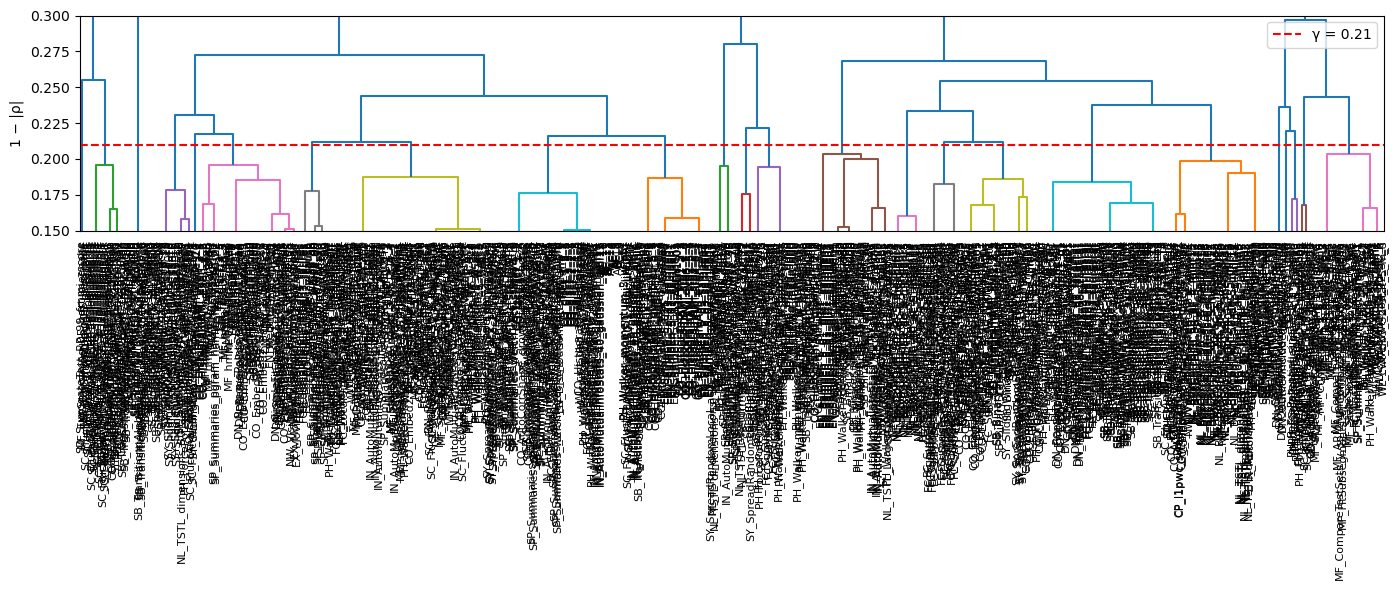

In [7]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform

nf = len(top_performers)
gamma = 0.21
# 1. absolute Pearson correlation → distance
corr = perf_scores[list(top_performers.index)[:nf]].corr()
dist = 1 - corr.abs().copy()
# np.fill_diagonal(dist.values, 0)          # ensure exact zeros on diagonal
dist = dist.clip(lower=0)  # handle floating-point negatives

# 2. condensed distance matrix (upper triangle, no diagonal)
condensed = squareform(dist, checks=False)

# 3. hierarchical clustering — complete linkage
Z = linkage(condensed, method="complete")

# 4. cut tree at distance threshold γ
clusters = fcluster(Z, t=gamma, criterion="distance")

# 5. summary
cluster_df = pd.DataFrame({"feature": list(top_performers.index)[:nf], "cluster": clusters})
print(f"{cluster_df['cluster'].nunique()} clusters from {len(cluster_df)} features")
print(cluster_df.sort_values("cluster"))

# 6. (optional) dendrogram
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(
    Z,
    labels=top_performers.index.tolist()[:nf],
    ax=ax,
    color_threshold=gamma,
    leaf_rotation=90,
    leaf_font_size=8,
)
ax.axhline(gamma, ls="--", color="red", label=f"γ = {gamma}")
ax.set_ylim(0.15, 0.3)
ax.set_ylabel("1 − |ρ|")
ax.legend()
plt.tight_layout()
plt.show()

## plot cluster scores


In [ ]:
# score_df = final_perf_scores
acc_mean = {}
acc_z_score = {}
c22_acc_mean = {}
c22_acc_z_score = {}

for cluster, df in cluster_df.groupby("cluster"):
    features = df["feature"].tolist()
    scores = perf_scores_norm_comb[features]
    acc_mean[cluster] = scores
    acc_z_score[cluster] = (scores - scores.mean()) / scores.std()

    c22_in_cluster = [f for f in features if f in fs.CATCH22]
    if c22_in_cluster:
        c22_scores = perf_scores_norm_comb[c22_in_cluster]  # .mean(axis=0)
        c22_acc_mean[cluster] = acc_mean[cluster][c22_in_cluster]
        c22_acc_z_score[cluster] = acc_z_score[cluster][c22_in_cluster] 


for title, whole, c22 in [("Mean Accuracy", acc_mean, c22_acc_mean)]: # ("Z Score of Combined Norm", acc_z_score, c22_acc_z_score)]: 
    whole_df = pd.DataFrame(whole)
    whole_df.columns = [f"Cluster {c}" for c in whole.keys()]
    whole_df = whole_df.sort_index()
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    # Box plots of cluster accuracies across datasets
    for col in whole_df.columns:
        fig.add_trace(
            go.Box(y=whole_df[col], name=col, showlegend=False),
            secondary_y=False,
        )

    # Individual catch22 feature normalized accuracy from c22_cluster_scores
    for cluster, scores in c22.items():
        fig.add_trace(
            go.Scatter(
                x=[f"Cluster {cluster}"] * len(scores),
                y=scores.values,
                mode="markers+text",
                name="Catch22 Features",
                showlegend=(cluster == list(c22.keys())[0]),
                marker=dict(color="red", size=10, symbol="diamond"),
                text=scores.index,
                textposition="top center",
                textfont=dict(size=8),
            ),
        )

    fig.update_layout(
        title="Cluster Accuracy Distribution with Catch22 Feature Positions",
        xaxis_title="Cluster",
        width=1100,
        height=600,
    )
    fig.update_yaxes(title_text="Normalized Accuracy", secondary_y=False)
    fig.show()

## Reproduce Fig5 - Performance pattern of clusters across features

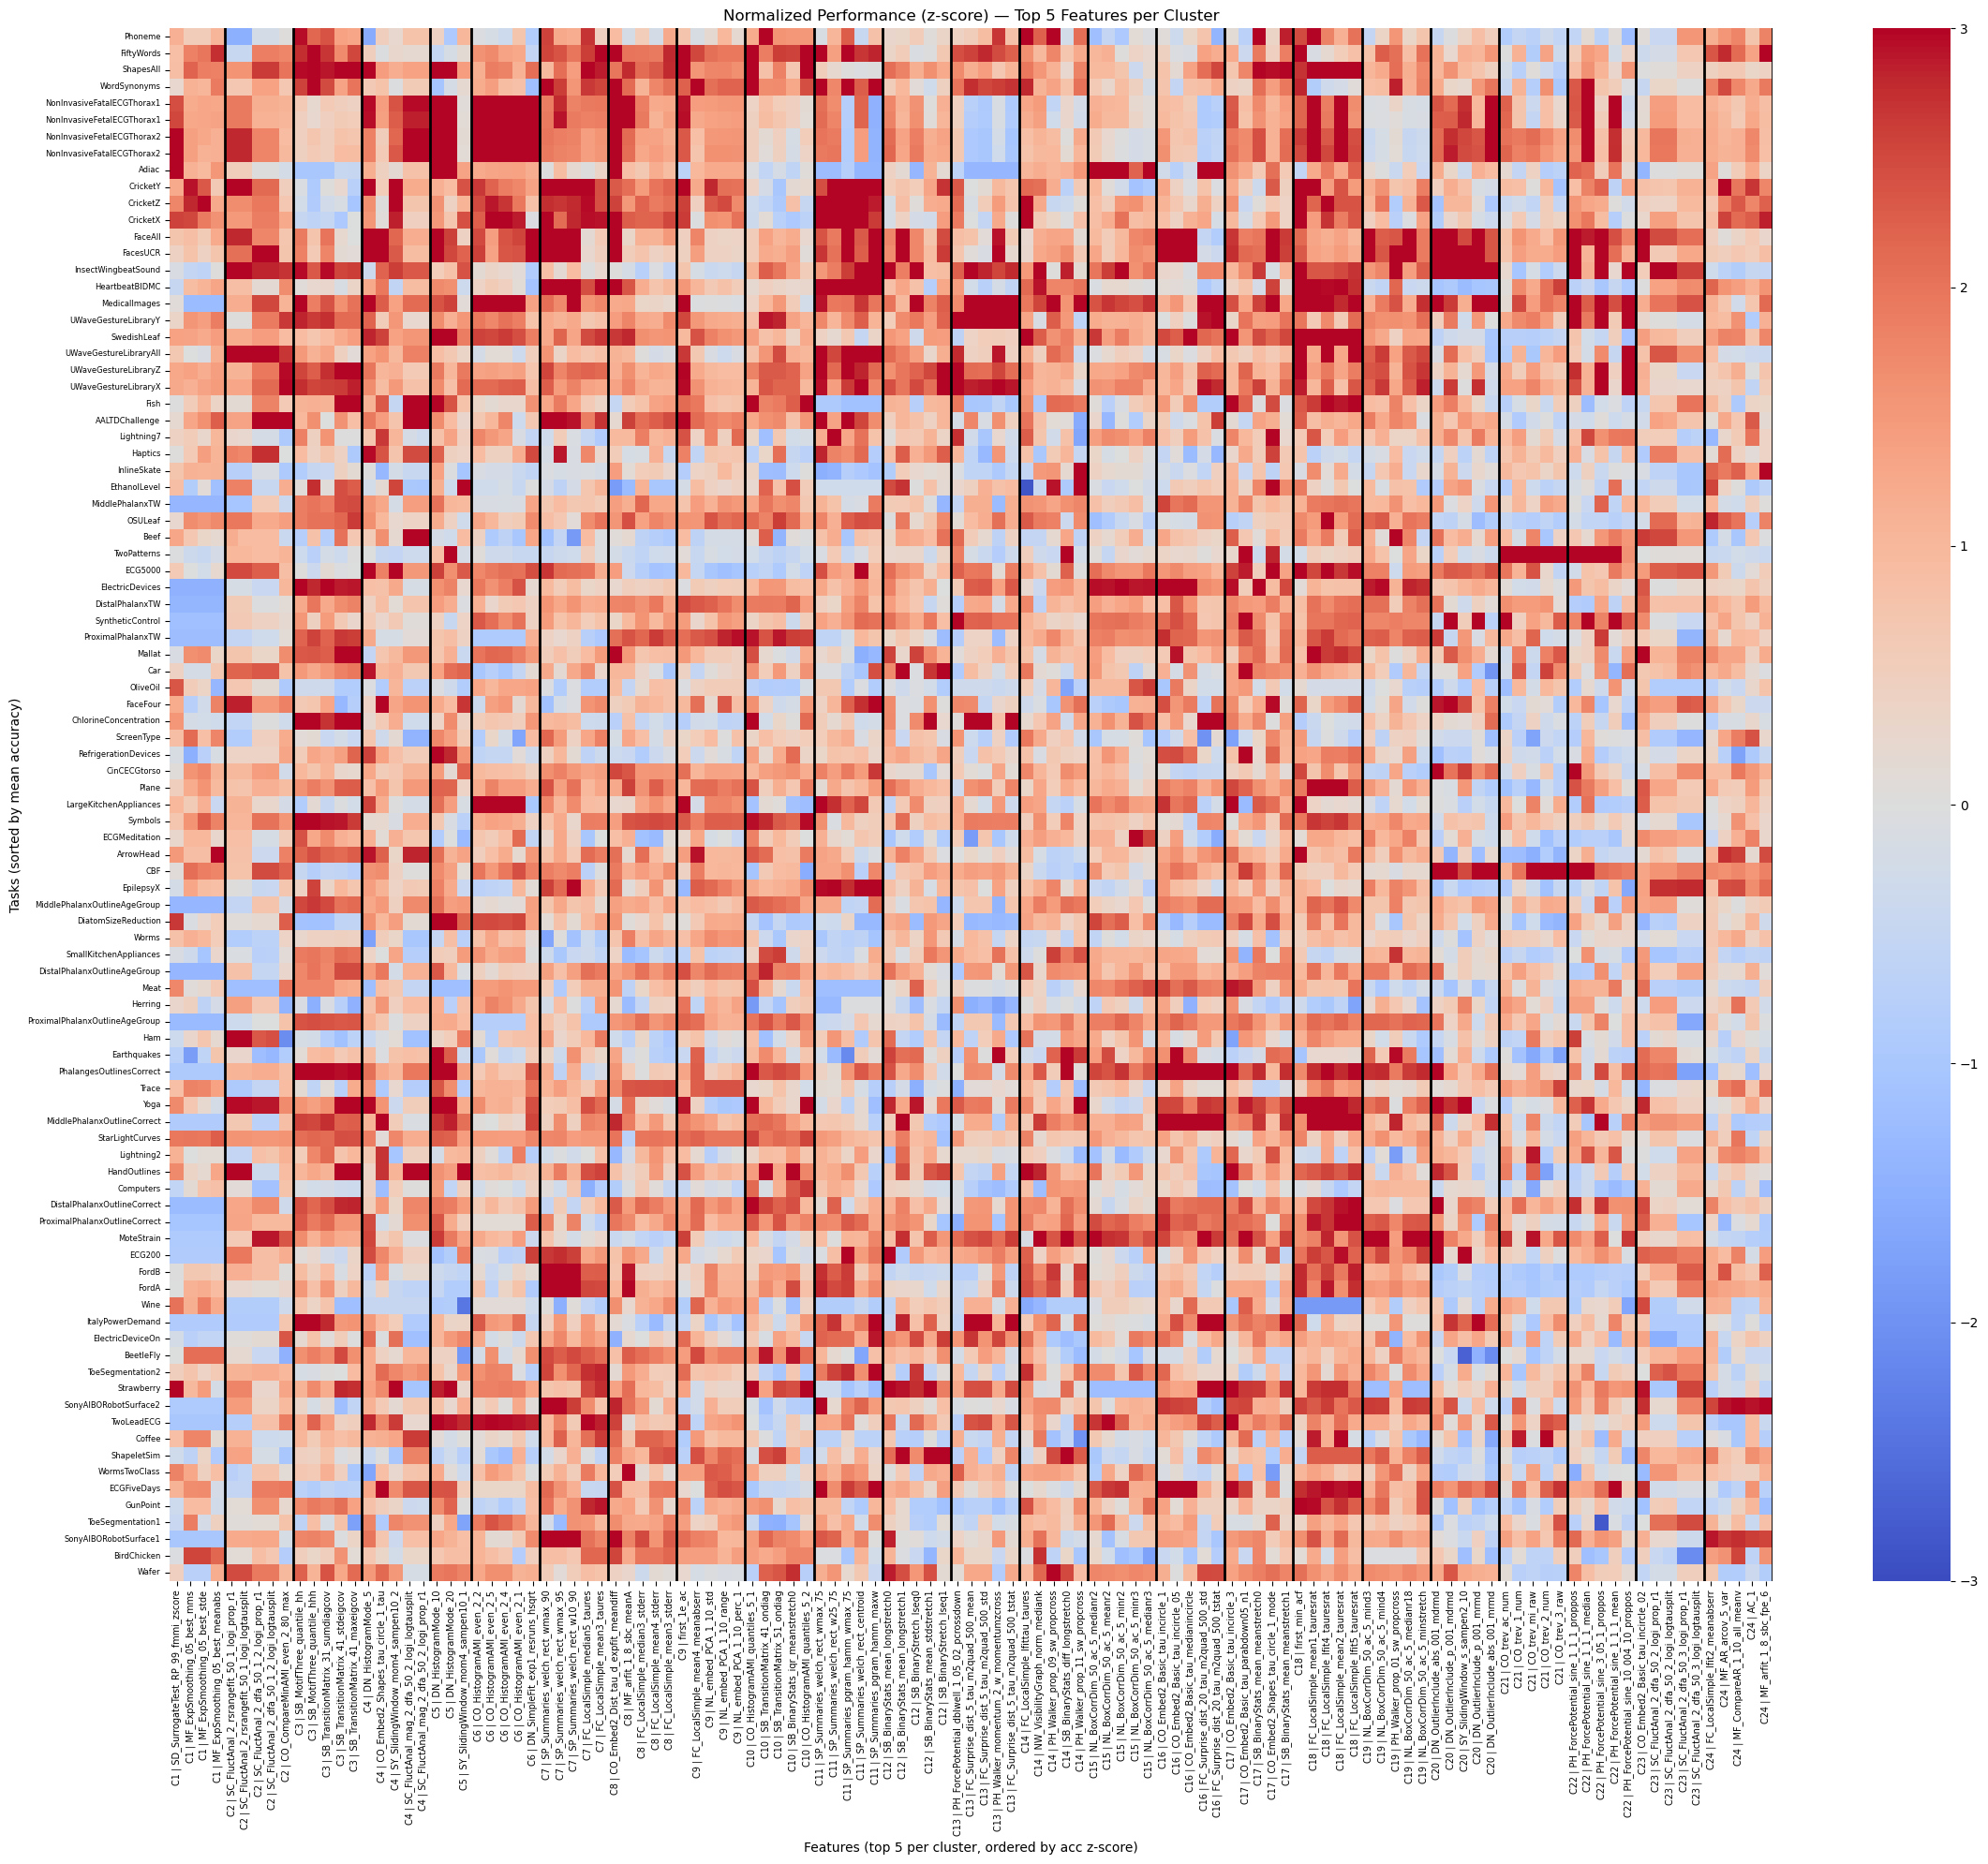

In [10]:
# Heatmap of z-scored performance across tasks and features
#
# X-axis (columns): Top 5 features per cluster, selected by highest acc_z_score
#   within each cluster. Features are grouped by cluster (ascending cluster id),
#   and within each cluster ordered by acc_z_score (best first, left to right).
#   Labels show cluster id and feature name: "C{id} | {feature}".
#
# Y-axis (rows): Tasks sorted by mean raw accuracy across all features
#   (ascending, so hardest tasks at the top, easiest at the bottom).
#   This ordering reflects task complexity.

import seaborn as sns

top_features = []
feature_xlabels = []
for cluster_id in sorted(acc_z_score.keys()):
    scores = acc_z_score[cluster_id].sort_values(ascending=False)
    top5 = scores.head(5).index.tolist()
    top_features.extend(top5)
    feature_xlabels.extend([f"C{cluster_id} | {f}" for f in top5])

# Keep only features present in perf_scores_norm
keep = [i for i, f in enumerate(top_features) if f in perf_scores_norm.columns]
feature_order = [top_features[i] for i in keep]
xlabels = [feature_xlabels[i] for i in keep]

# Build cluster labels for boundary lines
cluster_map = cluster_df.set_index("feature")["cluster"]
cluster_labels = cluster_map.loc[feature_order]

task_order = perf_scores.mean(axis=1).sort_values().index

heatmap_data = perf_scores_norm.loc[task_order, feature_order]
n_tasks = len(task_order)

fig, ax = plt.subplots(figsize=(max(20, len(feature_order) * 0.2), max(20, len(task_order) * 0.2)))
sns.heatmap(heatmap_data, cmap="coolwarm", center=0, ax=ax,
            xticklabels=xlabels, yticklabels=True, vmin=-3, vmax=3)

# Draw vertical lines at cluster boundaries
x_pos = 0
for cluster_id, group in cluster_labels.groupby(cluster_labels, sort=False):
    x_pos += len(group)
    ax.axvline(x=x_pos, color="black", linewidth=2)

ax.set_xlabel("Features (top 5 per cluster, ordered by acc z-score)")
ax.set_ylabel("Tasks (sorted by mean accuracy)")
ax.set_title("Normalized Performance (z-score) — Top 5 Features per Cluster")
ax.tick_params(axis="x", labelsize=7, rotation=90)
ax.tick_params(axis="y", labelsize=6)
plt.tight_layout()
plt.show()

## Conclusions
1. Cluster 5 seems to have all features outperforming the mean accuracy for majority of the datasets.
2. DN_HistogramMode_10 has the best combined accuracy, TODO: Why- what is this feature? 
3. Some C22 features end up in the same cluster, TODO: check their correlation distance
   

## Next Steps
1. Choose representative features from (9,10, 16)
2. Analyze model scores with just fit on cluster 5 and DN_HistogramMode_10 single-feature compared to C22 set accuracy
   